## Get Salzburg boundary and road netwrok
From OSM: https://pythongis.org/part2/chapter-09/nb/00-retrieving-osm-data.html

In [99]:
import osmnx as ox

In [100]:
place = "Salzburg, Austria"
aoi = ox.geocoder.geocode_to_gdf(place)

In [101]:
aoi.explore()

In [102]:
graph = ox.graph.graph_from_place(place)

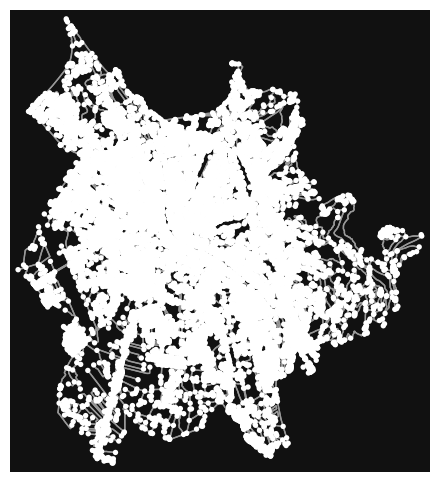

In [103]:
# Plot the streets
fig, ax = ox.plot.plot_graph(graph, figsize=(6, 6))

In [104]:
nodes, edges = ox.graph_to_gdfs(graph)
edges.head(2)

osmid      highway                   name  \
u        v          key                                                   
10778579 1829131772 0      29384239  residential             Stockerweg   
         1154784723 0    1046458330     tertiary  Maxglaner Hauptstraße   

                         oneway reversed     length  \
u        v          key                               
10778579 1829131772 0     False     True  50.219075   
         1154784723 0     False    False  54.908774   

                                                                  geometry  \
u        v          key                                                      
10778579 1829131772 0    LINESTRING (13.01821 47.79981, 13.01804 47.799...   
         1154784723 0    LINESTRING (13.01821 47.79981, 13.01822 47.799...   

                        lanes maxspeed  ref junction bridge tunnel width  \
u        v          key                                                    
10778579 1829131772 0     NaN      NaN  NaN      NaN    NaN    NaN   NaN   
         1154784723 0       2       50  NaN      NaN    NaN    NaN   NaN   

                        access service est_width  
u        v          key                           
10778579 1829131772 0      NaN     NaN       NaN  
         1154784723 0      NaN     NaN       NaN

Salzburg UTM EPSG: https://de.wikipedia.org/wiki/%C3%96sterreichisches_Bundesmeldenetz

Grid from gdf boundaries: https://dmnfarrell.github.io/plotting/geopandas-grids

In [121]:
def reassign_grid_id(grid_gdf):
    import geopandas as gpd

    # grid_gdf = your grid GeoDataFrame

    # Use centroid coordinates for sorting
    grid_gdf["centroid_x"] = grid_gdf.geometry.centroid.x
    grid_gdf["centroid_y"] = grid_gdf.geometry.centroid.y

    # Sort from top-left:
    # y descending = top to bottom
    # x ascending = left to right
    grid_gdf = grid_gdf.sort_values(
        by=["centroid_y", "centroid_x"],
        ascending=[False, True]
    ).reset_index(drop=True)

    # Assign grid IDs
    grid_gdf["grid_id"] = range(1, len(grid_gdf) + 1)

    # Optional: remove helper columns
    grid_gdf = grid_gdf.drop(columns=["centroid_x", "centroid_y"])
    return grid_gdf

In [107]:
import numpy as np
def create_grid(gdf=None, bounds=None, n_cells=10, overlap=False, crs="EPSG:29902"):
    """Create square grid that covers a geodataframe area
    or a fixed boundary with x-y coords
    returns: a GeoDataFrame of grid polygons
    see https://james-brennan.github.io/posts/fast_gridding_geopandas/
    """

    import geopandas as gpd
    import shapely

    if bounds != None:
        xmin, ymin, xmax, ymax= bounds
    else:
        xmin, ymin, xmax, ymax= gdf.total_bounds

    # get cell size
    cell_size = (xmax-xmin)/n_cells
    # create the cells in a loop
    grid_cells = []
    for x0 in np.arange(xmin, xmax+cell_size, cell_size):
        for y0 in np.arange(ymin, ymax+cell_size, cell_size):
            x1 = x0-cell_size
            y1 = y0+cell_size
            poly = shapely.geometry.box(x0, y0, x1, y1)
            #print (gdf.overlay(poly, how='intersection'))
            grid_cells.append(poly)

    cells = gpd.GeoDataFrame(grid_cells, columns=['geometry'],
                                     crs=crs)
    # cells["grid_area"] = round(cells.area/10000,1)
    
    if overlap == True:
        # cols = ['grid_id','geometry','grid_area']
        cells = cells.sjoin(gdf, how='inner').drop_duplicates('geometry')
        cells = cells[[cells.geometry.name]]
        cells = cells.reset_index().rename(columns={"index": "grid_id"})
        cells["grid_area_ha"] = round(cells.area/10_000,1)
    return cells

def create_hex_grid(gdf=None, bounds=None, n_cells=10, overlap=False, crs="EPSG:29902"):
    """Hexagonal grid over geometry.
    See https://sabrinadchan.github.io/data-blog/building-a-hexagonal-cartogram.html
    """

    from shapely.geometry import Polygon
    import geopandas as gpd
    if bounds != None:
        xmin, ymin, xmax, ymax= bounds
    else:
        xmin, ymin, xmax, ymax= gdf.total_bounds

    unit = (xmax-xmin)/n_cells
    a = np.sin(np.pi / 3)
    cols = np.arange(np.floor(xmin), np.ceil(xmax), 3 * unit)
    rows = np.arange(np.floor(ymin) / a, np.ceil(ymax) / a, unit)

    #print (len(cols))
    hexagons = []
    for x in cols:
      for i, y in enumerate(rows):
        if (i % 2 == 0):
          x0 = x
        else:
          x0 = x + 1.5 * unit

        hexagons.append(Polygon([
          (x0, y * a),
          (x0 + unit, y * a),
          (x0 + (1.5 * unit), (y + unit) * a),
          (x0 + unit, (y + (2 * unit)) * a),
          (x0, (y + (2 * unit)) * a),
          (x0 - (0.5 * unit), (y + unit) * a),
        ]))

    grid = gpd.GeoDataFrame({'geometry': hexagons},crs=crs)
    if overlap == True:
        cols = ['grid_id','geometry','grid_area']
        grid = grid.sjoin(gdf, how='inner').drop_duplicates('geometry')
        
        grid = grid[[grid.geometry.name]]
        grid = reassign_grid_id(grid)
        # grid = grid.reset_index().rename(columns={"index": "grid_id"})
        grid["grid_area_ha"] = round(grid.area/10_000,1)
    return grid

In [108]:
# import pylab as plt
epsg = "EPSG:31258" # 25833
aoi_utm = aoi.to_crs(epsg) 

# grid_utm = create_grid(aoi_utm, n_cells=75, overlap=True, crs=epsg)
grid_utm = create_hex_grid(aoi_utm, n_cells=30, overlap=True, crs=epsg)
grid = grid_utm.to_crs("EPSG:4326")
print(len(grid))

244


In [122]:
# grid.explore()

<Axes: >

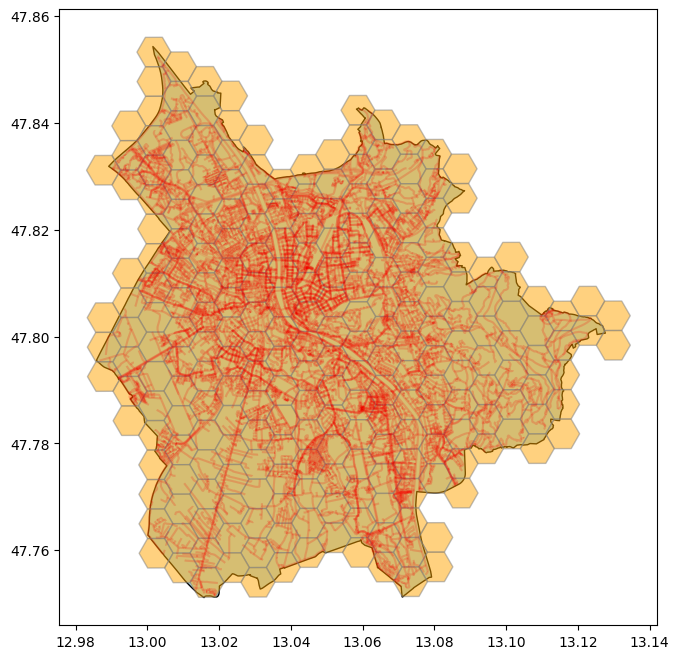

In [110]:
ax = aoi.plot(color='lightblue', edgecolor='black', figsize=(10, 8))
edges.plot(ax=ax, color='red', alpha=0.1)
grid.plot(ax=ax, color='orange', edgecolor='gray', alpha=0.5)

## Shortest path between two points
Find closest node to specified coordinates : https://www.geeksforgeeks.org/python/find-the-nearest-node-to-a-point-using-osmnx-distance-module/

Shortest path doc: https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html

Shortest path example: https://colab.research.google.com/github/mobook/MO-book/blob/main/notebooks/04/09-shortest-path-road-networks.ipynb#scrollTo=ZjGPTLE1T4gz

In [217]:
destination_coords = (47.812095362297846, 13.061987162495239)
origin_coords = (47.76, 13.02)

In [218]:
# import networkx as nx
origin_node = ox.distance.nearest_nodes(graph,
                                         origin_coords[1], origin_coords[0],
                                         return_dist=True)
destination_node = ox.distance.nearest_nodes(graph,
                                         destination_coords[1], destination_coords[0],
                                         return_dist=True)

origin_node_id = origin_node[0]
destination_node_id = destination_node[0]

shortest_path = ox.shortest_path(graph, origin_node_id, destination_node_id)#, "distance")

In [219]:
shortest_path_edges = ox.routing.route_to_gdf(graph, shortest_path, weight='length')
# shortest_path_edges.explore(color='red', )

<Axes: >

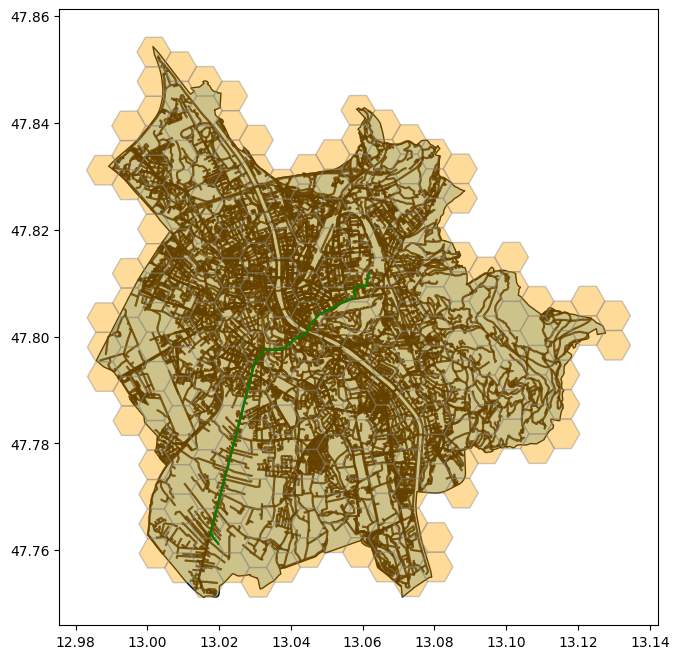

In [220]:
ax = aoi.plot(color='lightblue', edgecolor='black', figsize=(10, 8))
edges.plot(ax=ax, color='black', alpha=0.6, zorder=1)
grid.plot(ax=ax, color='orange', edgecolor='gray', alpha=0.4, zorder=2)
shortest_path_edges.plot(ax=ax, color='green', alpha=1, zorder=3)

Hazardous grid -> New route

In [221]:
import random
no_hazard_zones = 10
no_safety_zones = 5 
no_zones = 300
    
safety_grids = []
hazard_grids = []

while len(hazard_grids) != no_hazard_zones:
    id = random.randint(1, no_zones)
    hazard_grids.append(id)
    hazard_grids = list(set(hazard_grids))
    
print(hazard_grids)

while len(safety_grids) != no_safety_zones:
    id = random.randint(1, no_zones)
    if id not in (hazard_grids):
        safety_grids.append(id)
        safety_grids = list(set(safety_grids))
    
print(safety_grids)
print(list(set(safety_grids) & set(hazard_grids)))

[97, 227, 237, 92, 242, 116, 278, 183, 28, 31]
[257, 74, 48, 213, 57]
[]


In [222]:
hazard_grids_gdf = grid[grid['grid_id'].isin(hazard_grids)]
hazard_grids_gdf.head()

,geometry,grid_id,grid_area_ha
27,"POLYGON ((13.02802 47.8285, 13.03275 47.82851,...",28,32.6
30,"POLYGON ((13.07061 47.8286, 13.07535 47.82861,...",31,32.6
91,"POLYGON ((13.03526 47.80367, 13.03999 47.80369...",92,32.6
96,"POLYGON ((13.10622 47.80384, 13.11095 47.80385...",97,32.6
115,"POLYGON ((13.07786 47.79826, 13.08259 47.79827...",116,32.6


In [223]:
safety_grids_gdf = grid[grid['grid_id'].isin(safety_grids)]
safety_grids_gdf.head()

,geometry,grid_id,grid_area_ha
47,"POLYGON ((13.02097 47.8202, 13.0257 47.82021, ...",48,32.6
56,"POLYGON ((13.05648 47.81753, 13.06121 47.81754...",57,32.6
73,"POLYGON ((13.00684 47.80912, 13.01157 47.80913...",74,32.6
212,"POLYGON ((13.08511 47.76791, 13.08983 47.76792...",213,32.6


In [224]:
import networkx as nx
import geopandas as gpd

for gdf in [nodes, edges, hazard_grids_gdf]:
    gdf.drop(
        columns=["index_left", "index_right"],
        errors="ignore",
        inplace=True
    )

nodes_in_hazard = gpd.sjoin(
    nodes,
    hazard_grids_gdf,
    predicate="within",
    how="inner"
)

safe_graph = graph.copy()
safe_graph.remove_nodes_from(nodes_in_hazard.index)

edges_in_hazard = gpd.sjoin(
    edges,
    hazard_grids_gdf,
    predicate="intersects",
    how="inner"
)

safe_graph.remove_edges_from(edges_in_hazard.index)

isolated_nodes = list(nx.isolates(safe_graph))
safe_graph.remove_nodes_from(isolated_nodes)


In [225]:
# Get centroid coordinates
centroids = [
    (point.x, point.y)
    for point in safety_grids_gdf.geometry.centroid
]

# Get nearest graph node for each centroid
destination_nodes = [
    ox.distance.nearest_nodes(safe_graph, x, y)
    for x, y in centroids
]

# Calculate network distance from origin to each destination
distances = []

for node in destination_nodes:
    try:
        distance = nx.shortest_path_length(
            safe_graph,
            origin_node_id,
            node,
            weight="length"
        )
        distances.append(distance)
    except nx.NetworkXNoPath:
        distances.append(float("inf"))

# Find closest destination
closest_idx = min(range(len(distances)), key=distances.__getitem__)

destination_node_id = destination_nodes[closest_idx]
closest_distance = distances[closest_idx]

print("Closest destination:", destination_node_id)
print("Network distance:", closest_distance)

safe_shortest_path = ox.shortest_path(
    safe_graph,
    origin_node_id,
    destination_node_id,
    weight="length"
)

safe_shortest_path_edges = ox.routing.route_to_gdf(
    safe_graph,
    safe_shortest_path,
    weight="length"
)

distance = safe_shortest_path_edges.to_crs("EPSG:3857").length.sum()

print(distance)


C:\Users\jedimadistinction\AppData\Local\Temp\ipykernel_33728\416915192.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for point in safety_grids_gdf.geometry.centroid


Closest destination: 4610707099
Network distance: 6801.202724606745
10134.09414441072


<Axes: >

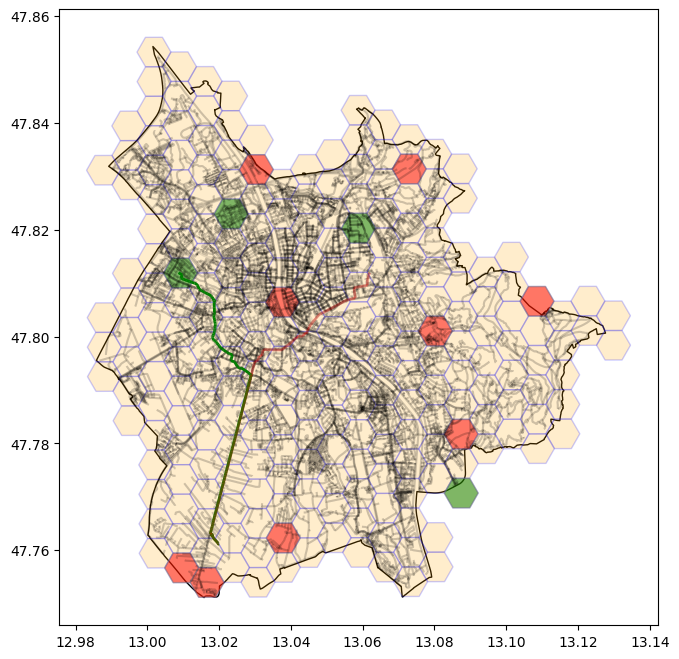

In [ ]:
# safe_shortest_path = ox.shortest_path(safe_graph, origin_node_id, destination_node_id)
# safe_shortest_path_edges = ox.routing.route_to_gdf(safe_graph, safe_shortest_path, weight='length')

ax = aoi.plot(color='white', edgecolor='black', figsize=(10, 8))
edges.plot(ax=ax, color='black', alpha=0.1)
grid.plot(ax=ax, color='orange', edgecolor='blue', alpha=0.2)
hazard_grids_gdf.plot(ax=ax, color='red', edgecolor='gray', alpha=0.5)
safety_grids_gdf.plot(ax=ax, color='green', edgecolor='gray', alpha=0.5)
safe_shortest_path_edges.plot(ax=ax, color='green', linewidth=2, alpha=1)
shortest_path_edges.plot(ax=ax, color='red', linewidth=2, alpha=0.3)

In [227]:
safe_shortest_path_edges['segment_id'] = safe_shortest_path_edges.reset_index().index

<Axes: >

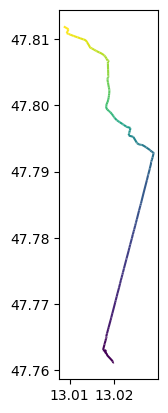

In [228]:
safe_shortest_path_edges.plot(column='segment_id')

In [229]:
safe_shortest_path_edges.explore()